In [1]:
import numpy as np
import pandas as pd
import sklearn.model_selection
import argparse, os, glob, re, warnings, shutil, pysam, vcf, subprocess, string
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
import statsmodels.api as sm
from Bio import Seq, SeqIO, AlignIO
from Bio.SeqUtils import lcc
from Bio.Seq import Seq
from Bio import Align
from Bio.Align import MultipleSeqAlignment
from Bio import pairwise2
from Bio.pairwise2 import format_alignment

import panel as pn
import panel.widgets as pnw
pn.extension()
from dna_features_viewer import GraphicFeature, GraphicRecord

from bokeh.plotting import figure
from bokeh.models import ColumnDataSource, Plot, Grid, Range1d
from bokeh.models.glyphs import Text, Rect
from bokeh.layouts import gridplot
import scipy.stats as st

df_isolate_metadata = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/isolate_metadata.csv")

personal_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly"
H37Rv_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF"

TRUST_data_dir = "~/TRUST_data_processing/processed_data"
df_trust_patients = pd.read_csv(f"{TRUST_data_dir}/combined_patient_WGS_data.csv")
tbtyper_culture = pd.read_csv("../lowAF_variant_calling/data/tbtyper_culture.csv")

df_assemblies = pd.read_csv("/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/data/TRUST_SR_samples_personal_genomes.csv")
df_ASM_QC = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/TRUST/hybridASM_QC.csv")

for i, row in df_trust_patients.iterrows():
    if not row['Original_ID'].startswith('S'):
        
        length_numerical = len(row['Original_ID'].split('-')[0])
            
        newID = 'S' + '0' * (4 - length_numerical) + row['Original_ID']
        df_trust_patients.loc[i, 'Original_ID'] = newID
        
    if not pd.isnull(row['Lineage']):
        if type(row['Lineage']) == float:
            df_trust_patients.loc[i, 'Lineage'] = str(int(row['Lineage']))
        else:
            df_trust_patients.loc[i, 'Lineage'] = str(row['Lineage'])
     
print(df_trust_patients.Lineage.value_counts())
            
F2_max = 0.03
h37Rv_path = "/n/data1/hms/dbmi/farhat/Sanjana/H37Rv"
h37Rv_seq = SeqIO.read(os.path.join(h37Rv_path, "GCF_000195955.2_ASM19595v2_genomic.gbff"), "genbank")
h37Rv_genes = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_genes_v4.csv"))
h37Rv_regions = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_v4.csv"))

h37Rv_coords = pd.read_csv(os.path.join(h37Rv_path, "h37Rv_coords_to_gene.csv"))
h37Rv_coords_dict = dict(zip(h37Rv_coords["pos"].values, h37Rv_coords["region"].values))

genomic_data_dir = "/n/data1/hms/dbmi/farhat/rollingDB/genomic_data"

LinToColor_Dict = {"1": "#DF83AC",
                   "2": "#7098CB",
                   "3": "#815D9F",
                   "4": "#E76956",
                  }

personal_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly"
H37Rv_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF"

# remove rRNAs, which are highly conserved. rrs, rrl, and rrf
rRNA_pos = []

for i, row in h37Rv_regions.query("Functional_Category=='stable RNAs' & Feature=='rRNA'").iterrows():
    print(row['Name'])
    rRNA_pos += list(np.arange(row['Start'], row['Stop'] + 1))
    
insertion_seqs_phages_pos = []

for i, row in h37Rv_regions.query("Functional_Category=='insertion seqs and phages'").iterrows():
    insertion_seqs_phages_pos += list(np.arange(row['Start'], row['Stop'] + 1))
    
insertion_seqs_phages_pos = np.unique(insertion_seqs_phages_pos)

gtf_cols = [
    "seqname",      # chromosome or contig
    "source",       # annotation source
    "feature",      # feature type (exon, CDS, gene, etc.)
    "start",        # 1-based start
    "end",          # 1-based end
    "score",        # numeric score or "."
    "strand",       # + or -
    "frame",        # 0,1,2 or "."
    "attribute"     # semicolon-delimited key-value pairs
]

Lineage
2      381
4      330
3       48
2,4      6
1        1
2,3      1
Name: count, dtype: int64
rrs
rrl
rrf


In [2]:
# these are from /home/sak0914/Mtb_Megapipe/kraken_db/custom_human_MTBC_genomes, which I downloaded from Max's paper
#, then excluded the TRUST samples and the 4 reference genomes
df_Max_samples = pd.read_csv("~/MtbLongitudinalDiversity/hybrid_assemblies/data/Max_addl_genomes.csv")

Rv2082_dir = "/n/data1/hms/dbmi/farhat/Sanjana/Rv2082_duplication/genomes"

In [3]:
df_Max_sample_metadata = pd.read_excel("~/MtbLongitudinalDiversity/hybrid_assemblies/data/SF2.GenomeSequencingMetadata.xlsx", sheet_name=None)

df_Max_sample_metadata = df_Max_sample_metadata['Mtb dataset Overview (n=151)'][['SampleID', 'Lineage']]

df_Max_sample_metadata['Coll2014'] = df_Max_sample_metadata['Lineage'].str.replace('lineage', '')



In [116]:
for i, row in df_Max_sample_metadata.iterrows():
    
    lineages_lst = row['Coll2014'].split(',')
    
    if len(lineages_lst) > 1:
        
        deepest_lineage = lineages_lst[0]
        
        for lineage in lineages_lst:
            
            if deepest_lineage in lineage:
                deepest_lineage = lineage
                
        df_Max_sample_metadata.loc[i, 'Coll2014'] = deepest_lineage
        
df_Max_sample_metadata['Lineage'] = df_Max_sample_metadata['Coll2014'].str[0]



In [117]:
df_Max_sample_metadata.Lineage.value_counts()



Lineage
4    62
2    61
1    15
3     7
6     3
5     2
8     1
Name: count, dtype: int64

In [124]:
H37Rv_Rv2082_seq = h37Rv_seq.seq[h37Rv_regions.query("Name=='Rv2081c'").Stop.values[0]:h37Rv_regions.query("Name=='Rv2083'").Start.values[0]]

# H37Rv_Rv2082_seq = h37Rv_seq.seq[2338436:h37Rv_regions.query("Name=='Rv2083'").Start.values[0]]

# print("H37Rv", len(H37Rv_Rv2082_seq))

# file.write(f">H37Rv_Rv2082_with_flanking\n")
# file.write(f"{str(H37Rv_Rv2082_seq)*2}\n")

Rv2082_Rv2083_intervening_region_lengths = {}

for sample in df_Max_samples.SampleID.values:

    ASM_seq = [(seq.id, seq.seq) for seq in SeqIO.parse(f"{Rv2082_dir}/{sample}/{sample}.HybridAsm.fasta", "fasta")][0][1]

    if os.path.isfile(f"{Rv2082_dir}/{sample}/liftoff.gff_polished"):
        
        gff_file = pd.read_csv(f"{Rv2082_dir}/{sample}/liftoff.gff_polished",
                               sep='\t',
                               comment='#',
                               header=None,
                               names=gtf_cols
                              ).query("feature=='gene'")

        lb = gff_file.query("attribute.str.contains('Rv2081c')").start.values[0]
        ub = gff_file.query("attribute.str.contains('Rv2083')").start.values[0]

        # print(sample, ub-lb)
        Rv2082_Rv2083_intervening_region_lengths[sample] = ub - lb

    # file.write(f">{sample}\n")
    # file.write(f"{str(ASM_seq[lb:ub])}\n")
    
len(Rv2082_Rv2083_intervening_region_lengths)

143

In [ ]:
# 2340874-2338065 = 2809


In [137]:
df_intervening_region_lengths = pd.DataFrame(Rv2082_Rv2083_intervening_region_lengths, index=[0]).T.reset_index()
df_intervening_region_lengths.columns = ['SampleID', 'Length']
df_intervening_region_lengths['DUP'] = (df_intervening_region_lengths['Length'] > 3000).astype(int)
df_intervening_region_lengths = df_intervening_region_lengths.merge(df_Max_sample_metadata, on='SampleID')



In [138]:
# possible duplication
df_intervening_region_lengths.query("DUP==1").Coll2014.value_counts()



Coll2014
3        6
5        2
4.1.2    2
4.1      2
4.1.1    1
4.2.1    1
3.1.1    1
Name: count, dtype: int64

In [142]:
df_intervening_region_lengths.query("Lineage=='5'")

,SampleID,Length,DUP,Lineage,Coll2014
30,N1176,5377,1,5,5
33,N1272,5455,1,5,5


In [139]:
df_intervening_region_lengths.query("DUP==0").Coll2014.value_counts()

Coll2014
2.2.1      36
2.2.2      15
1.1.2      12
4.1.2.1    11
4.8        10
4.3.3       7
4.4.1.1     6
4.1.1.3     6
2.2.1.1     5
6           3
1.2.2       2
4.6.2.2     2
4.4.1       2
4.5         2
1.1.1.1     1
4.3         1
4.3.2.1     1
4.1.2       1
4.3.2       1
8           1
4.6.2       1
4.9         1
4           1
Name: count, dtype: int64

In [133]:
df_intervening_region_lengths.query("WT != 0")

,SampleID,Length,WT,Lineage,Coll2014
21,M0017522_5,5471,1,4,4.1.1
23,N0004,5466,1,3,3
24,N0054,5466,1,3,3
30,N1176,5377,1,5,5
33,N1272,5455,1,5,5
34,N1274,5467,1,3,3
37,QC-3,5466,1,3,3
39,QC-5,5466,1,3,3
43,QC-9,5466,1,3,3
99,TB3251,5465,1,4,4.2.1


In [197]:
# mada samples are from Madagascar
# TB3251 and TB3334 are from Moldova. All TBNNNN samples are from Georgia and Moldova
df_intervening_region_lengths.query("WT==0 & Lineage=='4'")

,SampleID,Length,WT,Lineage,Coll2014
38,R20896,-3100,0,4,4.1.1.3
58,R30396,-3102,0,4,4.1.1.3
75,TB3169,-3101,0,4,4.1.2.1
77,TB3251,2684,0,4,4.2.1
78,TB3334,2684,0,4,4.1.2
92,mada_1-41,2683,0,4,4.1
107,mada_139,-3101,0,4,4.1.2.1
109,mada_2-31,2683,0,4,4.1


In [182]:
df_intervening_region_lengths.query("WT==0 & Lineage=='5'")

,SampleID,Length,WT,Lineage,Coll2014
15,N1176,2734,0,5,5
16,N1272,2734,0,5,5


In [198]:
# WT sequence
df_intervening_region_lengths.query("WT==1").Lineage.value_counts()

Lineage
2    49
4    32
1    14
Name: count, dtype: int64

In [199]:
df_intervening_region_lengths.query("WT==1 & Lineage=='4'").Coll2014.value_counts().sort_index()

Coll2014
4          1
4.1.1      1
4.1.1.3    2
4.1.2      2
4.1.2.1    8
4.3.2      1
4.3.2.1    1
4.3.3      2
4.4.1      1
4.4.1.1    5
4.5        2
4.6.2      1
4.8        4
4.9        1
Name: count, dtype: int64

In [200]:
# QC- samples are from the Netherlands
# MT_0080 is from Nunavik, Quebec
df_intervening_region_lengths.query("WT==1 & Coll2014 in ['4.1.1', '4.1.2', '4.1.2.1']")

,SampleID,Length,WT,Lineage,Coll2014
2,02_R0894,-3,1,4,4.1.2.1
3,02_R1708,-3,1,4,4.1.2.1
17,M0017522_5,-3,1,4,4.1.1
18,MT_0080,-3,1,4,4.1.2
28,QC-10,-3,1,4,4.1.2.1
30,QC-4,-3,1,4,4.1.2.1
33,QC-8,-3,1,4,4.1.2.1
95,mada_102,-3,1,4,4.1.2
97,mada_105,-3,1,4,4.1.2.1
106,mada_129,-3,1,4,4.1.2.1


In [192]:
df_isolate_metadata.dropna(subset='Internal_IDs').query("Internal_IDs.str.contains('02-R0894')")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,SAMPLE,RUN,DB_OF_ORIGIN,ISOLATION_DATE,ISOLATION_COUNTRY,ISOLATION_REGION,SPUTUM/CULTURE,UNPAIRED/PAIRED,Platform,Model,SPECIES,TaxID,ReleaseDate,LoadDate,Num_Runs,Internal_IDs,Combined_Runs
617,SAMN05916453,SAMN05916453,SRS20795314,SRR28393951,cetr,1/1/12,Peru,Lima,1.0,1.0,ILLUMINA,Illumina HiSeq 2500,Mycobacterium tuberculosis,1773.0,3/20/24 8:23,3/20/24 7:44,1,"Peru5149,02-R0894",SRR28393951


# IS6110 Elements

In [19]:
ground_truth_samples = os.listdir(personal_ref_dir)
len(ground_truth_samples)

179

In [20]:
num_IS6110_elements = {}

for sample in ground_truth_samples:
    
    df_IS6110 = pd.read_csv(f"{personal_ref_dir}/{sample}/PacBio/IS6110/{sample}.bed", sep='\t', header=None)
    num_IS6110_elements[sample] = len(df_IS6110)

In [24]:
df_IS6110_elements = pd.DataFrame(num_IS6110_elements, index=[0]).T.reset_index()
df_IS6110_elements.columns = ['SampleID', 'Count']
df_IS6110_elements = df_IS6110_elements.merge(df_trust_patients[['SampleID', 'pid', 'Coll2014', 'Lineage', 'F2']]).query("F2 <= @F2_max")

In [29]:
df_IS6110_elements.groupby('Lineage').Count.mean().sort_values()

Lineage
1     1.000000
4     9.000000
3    16.666667
2    22.484848
Name: Count, dtype: float64

In [34]:
df_IS6110_elements.Count.min(), df_IS6110_elements.Count.max()

(1, 25)

In [48]:
df_IS6110_elements.query("Lineage=='4'")

,SampleID,Count,pid,Coll2014,Lineage,F2
1,MFS-104,9,T0186,4.8,4,0.009906
2,MFS-105,9,T0186,4.8,4,0.007788
3,MFS-106,14,T0188,4.3.3,4,0.005929
8,MFS-117,12,T0201,4.8,4,0.009178
17,MFS-136,3,T0227,4.1.1.1,4,0.007964
...,...,...,...,...,...,...
167,MFS-755,3,T0192,4.1.1.1,4,0.008691
170,MFS-767,3,T0345,4.1.1.1,4,0.008649
175,MFS-83,3,T0165,4.1.1.1,4,0.008878
176,MFS-877,3,T0192,4.1.1.1,4,0.007714


<Axes: xlabel='Lineage', ylabel='Count'>

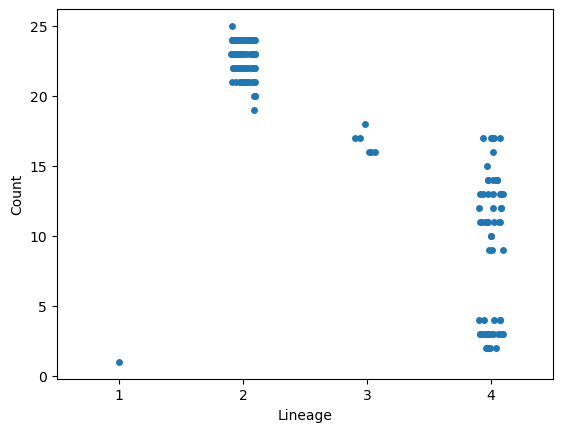

In [30]:
sns.stripplot(data=df_IS6110_elements,
              x='Lineage',
              y='Count',
              order=[1, 2, 3, 4]
             )

# Sniffles on PacBio reads aligned to H37Rv

In [4]:
df_assemblies.ASM.nunique()

154

In [5]:
all_samples = os.listdir(H37Rv_ref_dir)

In [6]:
df_F2 = pd.DataFrame(columns = ['SampleID', 'F2'])

for i, sample in enumerate(all_samples):
    F2 = pd.read_csv(f"{H37Rv_ref_dir}/{sample}/lineage/F2_Coll2014.txt", sep='\t', header=None)[0].values[0]
    df_F2.loc[i, :] = [sample, float(F2)]

In [7]:
len(df_F2), len(df_F2.query("F2 <= 0.03"))

(767, 738)

In [8]:
set(df_trust_patients.query("F2 <= 0.03").SampleID).symmetric_difference(df_F2.query("F2 <= 0.03").SampleID)

set()

In [9]:
df_keep_samples = df_trust_patients.query("F2 <= 0.03 & Sampling_Week <= 2")[['pid', 'SampleID', 'Sampling_Week', 'Lineage']].sort_values(['pid', 'Sampling_Week']).drop_duplicates(subset='pid', keep='first')
len(df_keep_samples)

395

In [12]:
pilon_VCF_all = []
pilon_VCF_LR = []

for i, row in df_keep_samples.iterrows():
    
    sample = row['SampleID']
    fName = f"{H37Rv_ref_dir}/{sample}/pilon/{sample}_SNPs.vcf"
    assert os.path.isfile(fName)
    
    pilon_VCF_all.append(fName)
    
    if sample in ground_truth_samples:
        pilon_VCF_LR.append(fName)
        
len(pilon_VCF_LR), len(pilon_VCF_all)

(110, 395)

In [13]:
df_keep_samples.Lineage.value_counts()

Lineage
2    194
4    172
3     28
1      1
Name: count, dtype: int64

In [135]:
df_keep_samples.loc[(df_keep_samples['SampleID'].isin(samples_Rv2082_dup)) & (df_keep_samples['Lineage']=='4'), 'Lineage'] = '4 DUP'

In [146]:
df_keep_samples[['SampleID', 'Lineage']].to_csv("../lowAF_variant_calling/data/trees/samples_lineage_annot.tsv", sep='\t', index=False)

In [121]:
df_trust_patients.query("F2 <= 0.03 & SampleID in @ground_truth_samples & Sampling_Week <= 2").pid.nunique(), df_trust_patients.query("F2 <= 0.03 & Sampling_Week <= 2").pid.nunique()

(110, 395)

In [122]:
pd.Series(pilon_VCF_all).to_csv("~/MtbLongitudinalDiversity/lowAF_variant_calling/data/trees/pilon_VCFs_lowF2.txt", sep='\t', header=None, index=False)
pd.Series(pilon_VCF_LR).to_csv("~/MtbLongitudinalDiversity/lowAF_variant_calling/data/trees/LR_samples/pilon_VCFs_lowF2.txt", sep='\t', header=None, index=False)

In [14]:
df_SV_LR = []

for sample in ground_truth_samples:
    
    df_SV = pd.read_csv(f"{personal_ref_dir}/{sample}/PacBio/SV_detection/{sample}.noQC.norm.tsv", sep='\t')
    df_SV['SampleID'] = sample
    df_SV_LR.append(df_SV)
    
df_SV_LR = pd.concat(df_SV_LR)

In [15]:
# this is the full Rv2081c-Rv2083 region
start = 2338065
end = 2341815

df_Rv2082_SV = df_SV_LR.query("POS >= @start & POS <= @end & SVLEN >= 2600 & SVLEN <= 2700 & FILTER != 'SUPPORT_MIN'")

samples_Rv2082_dup = df_Rv2082_SV.merge(df_trust_patients[['pid', 'SampleID', 'Coll2014', 'Lineage', 'F2']]).query("F2 <= @F2_max").query("SVTYPE=='DUP'").SampleID.unique()

len(samples_Rv2082_dup)

8

In [18]:
df_SV_LR.query("POS >= @start & POS <= @end & SVLEN >= 2600 & SVLEN <= 10000 & FILTER != 'SUPPORT_MIN'")

,POS,REF,ALT,QUAL,FILTER,SVTYPE,SVLEN,END,COVERAGE,VAF,SampleID
117,2338128,C,<DUP>,59.0,PASS,DUP,2631,2340759,"55,77,72,71,49",0.244,MFS-135
121,2340282,G,GCCAAGAACCCGGATTATCGTGGGCTGCCGGGCTACGCGACAACGG...,60.0,PASS,INS,2659,2340282,"75,74,74,73,45",0.378,MFS-135
122,2340735,A,ACCCCAACCACGACATCGCCACGGTAGCCAAGGCTAGATCGCCAGC...,60.0,MOSAIC_VAF,INS,2663,2340735,"74,71,69,45,49",0.087,MFS-135
288,2338128,C,<DUP>,58.0,MOSAIC_VAF,DUP,2631,2340759,"40,54,54,54,34",0.161,MFS-15
289,2339849,A,ACCCCCAGCCCGGCACCGATCGCGCCACCAACCACCGACAACGCCA...,60.0,PASS,INS,2662,2339849,"52,53,54,52,53",0.444,MFS-15
225,2338128,C,<DUP>,59.0,PASS,DUP,2631,2340759,"188,418,487,456,224",0.269,MFS-308
241,2340047,G,GGACCCATCTCGGTGCCGCGGTCACACCCTCCTCACCCGCAGCAGG...,60.0,MOSAIC_VAF,INS,2634,2340047,"499,501,495,489,464",0.036,MFS-308
245,2340477,C,CACACCACCCCCACGGCTACCTCAGCCAACCCGACCCCGACACACC...,60.0,PASS,INS,5309,2340477,"500,475,469,461,216",0.267,MFS-308
198,2338128,C,<DUP>,59.0,PASS,DUP,2631,2340759,"151,323,383,373,175",0.259,MFS-309
208,2339614,G,GGCAACAGCGCCGTTATCCCCACAGTCGTTGGGCCAGTCGTTCACC...,60.0,MOSAIC_VAF,INS,5310,2339614,"385,389,395,400,390",0.071,MFS-309


In [112]:
df_SV_LR.query("POS >= @start & POS <= @end & SampleID in @samples_Rv2082_dup & SVTYPE=='INV'")#.query("SVLEN >= 250 & SVLEN <= 350")

,POS,REF,ALT,QUAL,FILTER,SVTYPE,SVLEN,END,COVERAGE,VAF,SampleID
243,2340227,T,<INV>,60.0,SUPPORT_MIN,INV,948,2341175,"498,485,457,217,225",0.003,MFS-308
372,2339509,C,<INV>,60.0,SUPPORT_MIN,INV,205832,2545341,"37,43,38,51,50",0.023,MFS-557
288,2338463,T,<INV>,60.0,SUPPORT_MIN,INV,1735329,4073792,"21,33,22,28,25",0.043,MFS-737
290,2340245,C,<INV>,60.0,SUPPORT_MIN,INV,95256,2435501,"39,40,33,25,28",0.029,MFS-737


In [12]:
df_SV_LR.query("POS >= @start & POS <= @end & FILTER != 'SUPPORT_MIN'").query("SampleID=='MFS-308'")

,POS,REF,ALT,QUAL,FILTER,SVTYPE,SVLEN,END,COVERAGE,VAF,SampleID
225,2338128,C,<DUP>,59.0,PASS,DUP,2631,2340759,"188,418,487,456,224",0.269,MFS-308
229,2338214,G,GACACGACCACTCCTATTACTACCACCGGGGCAGCGAGGCGTTGCG...,60.0,MOSAIC_VAF,INS,112,2338214,"192,193,445,448,472",0.018,MFS-308
231,2338666,A,<DUP>,60.0,MOSAIC_VAF,DUP,589,2339255,"429,470,490,497,499",0.008,MFS-308
239,2339800,C,<DUP>,54.0,MOSAIC_VAF,DUP,260,2340060,"492,503,503,499,464",0.006,MFS-308
241,2340047,G,GGACCCATCTCGGTGCCGCGGTCACACCCTCCTCACCCGCAGCAGG...,60.0,MOSAIC_VAF,INS,2634,2340047,"499,501,495,489,464",0.036,MFS-308
245,2340477,C,CACACCACCCCCACGGCTACCTCAGCCAACCCGACCCCGACACACC...,60.0,PASS,INS,5309,2340477,"500,475,469,461,216",0.267,MFS-308


In [23]:
df_trust_patients.query("SampleID in @samples_Rv2082_dup").sort_values('Sampling_Week').drop_duplicates(subset='pid')[['SampleID', 'pid', 'Coll2014', 'Lineage']]

,SampleID,pid,Coll2014,Lineage
109,MFS-737,T0096,3.1.1,3
328,MFS-557,T0073,3.1.1,3
678,MFS-15,T0030,3,3
707,MFS-5,T0013,3.1.1,3
746,MFS-135,T0225,3,3
776,MFS-308,T0291,4.1.2,4
333,MFS-566,T0097,3,3


In [19]:
df_trust_patients.query("SampleID in @samples_Rv2082_dup").dropna(subset='Lineage').groupby('pid')['SampleID'].nunique()

pid
T0013    1
T0030    1
T0073    1
T0096    1
T0097    1
T0225    1
T0291    2
Name: SampleID, dtype: int64

In [14]:
df_trust_patients.query("pid=='T0096'")

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov Any Mean,Cov Unam Perc,Perc. Reads Mapped,...,duration_of_use_meth,duration_of_use_mandrax,lca,fib4,prevtb_outcome,F2,Coll2014,Freschi2020,Lineage,Sampling_Week
109,T0096,S0096-01,MFS-737,MFS-737_lib73367,1.0,NaN,1.0,407.83,1.0,0.9873,...,NaN,NaN,2.0,0.659169,NaN,0.011066,3.1.1,3.1.1.i1,3,1


In [118]:
Rv2082_start = h37Rv_regions.query("Name=='Rv2082'").Start.values[0]
Rv2082_end = h37Rv_regions.query("Name=='Rv2082'").Stop.values[0]

In [16]:
df_SV_LR.query("SampleID=='MFS-520'").query("POS > 2337000")# & POS <= @end")

,POS,REF,ALT,QUAL,FILTER,SVTYPE,SVLEN,END,COVERAGE,VAF,SampleID
135,2347407,CGCACCCGGCTCCGCCGCGCTTGCGATCGCCACTGGACCCAACAAG...,C,60.0,PASS,DEL,-57,2347464,"37,39,39,39,39",1.000,MFS-520
136,2352065,C,CCTCGCCTGGGCTGGCGAGCAGACGCAAAATCCCCCGCACGCCCGG...,60.0,PASS,INS,68,2352065,"26,27,29,29,29",0.931,MFS-520
137,2365410,GCGATGAACCGCCCCGGCATGTCCGGAGACTCCAGTTCTTGGAAAG...,G,60.0,PASS,DEL,-1358,2366768,"42,41,38,38,43",0.975,MFS-520
138,2387409,ACCGGCACCGCGGGCACCTCCGGCGCCGCCGGTGCCACCATCGCCA...,A,60.0,PASS,DEL,-171,2387580,"37,39,38,38,43",1.000,MFS-520
139,2401825,TGGCTCCTCCTCACCCCGTTACCCGGGGCGCATCGTCGCCGAGCTC...,T,60.0,PASS,DEL,-58,2401883,"33,34,34,34,37",1.000,MFS-520
...,...,...,...,...,...,...,...,...,...,...,...
242,4213873,G,GCCACACCAGGGGAACCCCCCCCACCCCCCCCCCCCCCCCCCCCCC...,60.0,SUPPORT_MIN,INS,155,4213873,"42,40,39,39,39",0.026,MFS-520
243,4276075,G,<INV>,60.0,SUPPORT_MIN,INV,810,4276885,"39,39,40,42,40",0.025,MFS-520
244,4353294,TAAACCACCCACACCCCCCATGCCCATCGCCGGACCCGAACCGGCC...,T,60.0,PASS,DEL,-51,4353345,"49,48,47,48,47",0.958,MFS-520
245,4385978,C,CCCCTGCAATGCCGGTCAACGGCTCCGCAAATAGTCGATGCGGTCA...,60.0,MOSAIC_VAF,INS,943,4385978,"38,34,37,38,40",0.081,MFS-520


In [119]:
df_SV_LR.query("POS > @start & POS <= @end & SVLEN >= 5300 & SVLEN <= 5400 & FILTER != 'SUPPORT_MIN' & VAF >= 0.1")

,POS,REF,ALT,QUAL,FILTER,SVTYPE,SVLEN,END,COVERAGE,VAF,SampleID
245,2340477,C,CACACCACCCCCACGGCTACCTCAGCCAACCCGACCCCGACACACC...,60.0,PASS,INS,5309,2340477,"500,475,469,461,216",0.267,MFS-308
216,2340477,C,CACACCACCCCCACGGCTACCTCAGCCAACCCGACCCCGACACACC...,60.0,MOSAIC_VAF,INS,5311,2340477,"389,385,376,375,178",0.202,MFS-309


In [129]:
h37Rv_regions.query("Name=='Rv2081c'")#.Start.values[0]

,Refseq_ID,Mycobrowser_Version,Feature,Start,Stop,Score,Strand,Frame,Locus,Name,...,SWISS-MODEL,Orthologues M. leprae,Orthologues M. marinum,Orthologues M. smegmatis,Orthologues M. bovis,Orthologues M. lepromatosis,Orthologues M. tuberculosis,Orthologues M. abscessus,Orthologues M. haemophilum,Orthologues M. orygis
2227,NC_000962.3,Mycobrowser_v4,CDS,2338065,2338505,.,-,0.0,Rv2081c,Rv2081c,...,P9WLK5,NaN,NaN,NaN,Mb2107c,NaN,NaN,NaN,NaN,NaN


In [75]:
h37Rv_regions.query("Name=='Rv2081c'").Start.values[0], h37Rv_regions.query("Name=='Rv2083'").Start.values[0]

(2338065, 2340871)

In [200]:
h37Rv_regions.query("Name=='Rv2081c'").Start.values[0], h37Rv_regions.query("Name=='Rv2083'").Stop.values[0]

(2338065, 2341815)

In [202]:
df_assemblies.query("SampleID=='MFS-308'").ASM.values[0]

'/n/data1/hms/dbmi/farhat/rollingDB/TRUST/PacBio_Illumina_hybridASM/S0291-01/FlyeAssembly_I3_PilonPolishing/pilon_IllPE_Polishing_I3_Asm_ChangeSNPsINDELsOnly/S0291-01.Flye.I3Asm.PilonPolished.fasta'

In [204]:
df_assemblies.query("SampleID=='MFS-308'").PacBio_FQ_PATH.values[0]

'/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio/TRUST_PacBio_Set3_230124/m64142_221216_110244.bc2009--bc2009.hifi_reads.fastq.gz'

In [208]:
sample = 'MFS-308'
haplotype_1 = [(seq.id, seq.seq) for seq in SeqIO.parse(f"{personal_ref_dir}/{sample}/PacBio/personal_aln/hifiasm/Rv2081c-Rv2083.fasta.bp.hap1.p_ctg.fasta", "fasta")]
haplotype_2 = [(seq.id, seq.seq) for seq in SeqIO.parse(f"{personal_ref_dir}/{sample}/PacBio/personal_aln/hifiasm/Rv2081c-Rv2083.fasta.bp.hap2.p_ctg.fasta", "fasta")]

len(haplotype_1), len(haplotype_2)

(1, 1)

In [209]:
len(haplotype_1[0][1]), len(haplotype_2[0][1])

(42668, 42668)

In [212]:
str(haplotype_1[0][1]) == str(haplotype_2[0][1])

True

In [211]:
haplotype_2[0][1]

Seq('GTCGCGAGTCAACTCGTGCAGGTGCCACGCCGCGTCCACCTTGGACCGCAACAC...CAG')

In [39]:
start = 2338129
end = 2340759

In [374]:
samples_with_dup = ['MFS-5', 'MFS-15', 'MFS-135', 'MFS-557', 'MFS-566', 'MFS-737', 'MFS-308', 'MFS-309']

with open("Rv2081c_Rv2083_seq.fasta", "w+") as file:
        
    H37Rv_Rv2081c_seq = h37Rv_seq.seq[h37Rv_regions.query("Name=='Rv2081c'").Start.values[0]-1:h37Rv_regions.query("Name=='Rv2081c'").Stop.values[0]]
    
    # include all of Rv2081c - Rv2083, inclusive
    # H37Rv_Rv2082_seq = h37Rv_seq.seq[h37Rv_regions.query("Name=='Rv2081c'").Start.values[0]-1:h37Rv_regions.query("Name=='Rv2083'").Stop.values[0] + 1]
    # H37Rv_Rv2082_seq = h37Rv_seq.seq[h37Rv_regions.query("Name=='Rv2081c'").Stop.values[0]-1:h37Rv_regions.query("Name=='Rv2083'").Start.values[0] + 1]
    
    H37Rv_Rv2083_seq = h37Rv_seq.seq[h37Rv_regions.query("Name=='Rv2083'").Start.values[0]-1:h37Rv_regions.query("Name=='Rv2083'").Stop.values[0]]
    
    start = 2338129
    end = 2340759
    H37Rv_Rv2082_seq = h37Rv_seq.seq[start-1:end]
    
    print("H37Rv", len(H37Rv_Rv2081c_seq), len(H37Rv_Rv2082_seq), len(H37Rv_Rv2083_seq))
    
    file.write(f">H37Rv\n")
    file.write(f"{str(H37Rv_Rv2082_seq)}\n")

    for sample in samples_with_dup:

        # df_IS6110 = pd.read_csv(f"{personal_ref_dir}/{sample}/PacBio/IS6110/{sample}.bed", sep='\t', header=None)

        ASM_seq = [(seq.id, seq.seq) for seq in SeqIO.parse(df_assemblies.query("SampleID==@sample").ASM.values[0], "fasta")][0][1]

        gff_file = pd.read_csv(f"{personal_ref_dir}/{sample}/assembly/H37Rv.liftoff.gff_polished",
                               sep='\t',
                               comment='#',
                               header=None,
                               names=gtf_cols
                              ).query("feature=='gene'")

        lb = gff_file.query("attribute.str.contains('Rv2081c')").start.values[0]
        ub = gff_file.query("attribute.str.contains('Rv2083')").start.values[0]
        
        print(sample, gff_file.query("attribute.str.contains('Rv2081c')").end.values[0] - gff_file.query("attribute.str.contains('Rv2081c')").start.values[0] + 1, ub-lb, gff_file.query("attribute.str.contains('Rv2083')").end.values[0] - gff_file.query("attribute.str.contains('Rv2083')").start.values[0] + 1)

        file.write(f">{sample}\n")
        file.write(f"{str(ASM_seq[lb - 1 : ub + 1])}\n")

H37Rv 441 2631 945
MFS-5 440 5466 945
MFS-15 440 5466 945
MFS-135 440 5466 945
MFS-557 440 5466 945
MFS-566 440 5466 945
MFS-737 440 5466 945
MFS-308 442 8111 945
MFS-309 442 8111 945


In [6]:
dup_seq = [(seq.id, seq.seq) for seq in SeqIO.parse("Rv2081c_Rv2083_seq.fasta", "fasta")]

In [7]:
dup_seq

[('H37Rv',
  Seq('GCTGCTGGCATGCAGGTGGAGTGCACAGACACGGCAGCTGCAATAGCCTTACGC...GGT')),
 ('MFS-5',
  Seq('CTACGGCGTCCCCGACAACGAAACCGACCTACTGCGGTCGCCCAGGCCAAGGTG...GAT')),
 ('MFS-15',
  Seq('CTACGGCGTCCCCGACAACGAAACCGACCTACTGCGGTCGCCCAGGCCAAGGTG...GAT')),
 ('MFS-135',
  Seq('CTACGGCGTCCCCGACAACGAAACCGACCTACTGCGGTCGCCCAGGCCAAGGTG...GAT')),
 ('MFS-557',
  Seq('CTACGGCGTCCCCGACAACGAAACCGACCTACTGCGGTCGCCCAGGCCAAGGTG...GAT')),
 ('MFS-566',
  Seq('CTACGGCGTCCCCGACAACGAAACCGACCTACTGCGGTCGCCCAGGCCAAGGTG...GAT')),
 ('MFS-737',
  Seq('CTACGGCGTCCCCGACAACGAAACCGACCTACTGCGGTCGCCCAGGCCAAGGTG...GAT')),
 ('MFS-308',
  Seq('CTACGGCGTCCCCGACAACGAAACCGACCTACTGCGGTCGCCCAGGCCAAGGTG...GAT')),
 ('MFS-309',
  Seq('CTACGGCGTCCCCGACAACGAAACCGACCTACTGCGGTCGCCCAGGCCAAGGTG...GAT'))]

In [190]:
start = 2338129
end = 2340759

df_lcc = pd.DataFrame({'LCC': lcc.lcc_mult(dup_seq[0][1], 50)})
df_lcc['POS'] = df_lcc.index.values + 1

df_lcc['POS'] += start

len(df_lcc)

2582

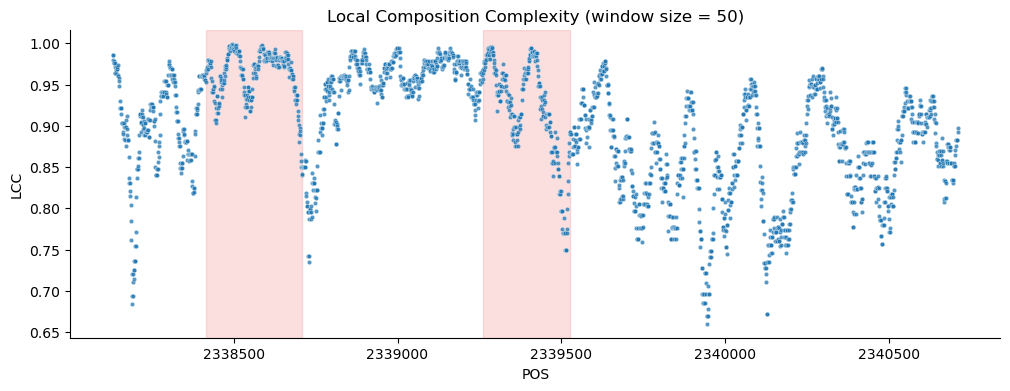

In [194]:
fig, ax = plt.subplots(figsize=(12, 4))

sns.scatterplot(data=df_lcc,
                x='POS',
                y='LCC',
                ax=ax,
                s=10,
                alpha=0.75
               )

high_SNP_density_bounds = [2338416, 2338707, 2339261, 2339525]
# # high_SNP_density_bounds = [2338416, 2338961, 2339261, 2339525]

# for pos in high_SNP_density_bounds:
#     plt.axvline(x=pos, color='darkred', zorder=0, linestyle='--', linewidth=1,)
    
regions = [
    (high_SNP_density_bounds[0], high_SNP_density_bounds[1]),
    (high_SNP_density_bounds[2], high_SNP_density_bounds[3])
]

for start, end in regions:
    ax.axvspan(start, end, color='lightcoral', alpha=0.25, zorder=0)

plt.ticklabel_format(style='plain', axis='both')

plt.title('Local Composition Complexity (window size = 50)')
plt.ylabel('LCC')
sns.despine()
plt.savefig("duplication_region_LCC.svg", bbox_inches='tight')

In [183]:
ax.get_xticks()

array([2338000., 2338500., 2339000., 2339500., 2340000., 2340500.,
       2341000.])

In [72]:
df_trust_patients.query("SampleID in ['MFS-588', 'MFS-559', 'MFS-701', 'MFS-746', 'MFS-308', 'MFS-35']")[['SampleID', 'Coll2014']].merge(tbtyper_culture)

,SampleID,Coll2014,mix_phylotypes,mix_props,n_phy,defaultParams
0,MFS-559,4.1.2,4.1.2,1.0,1,1
1,MFS-746,4.1.2,4.1.2,1.0,1,1
2,MFS-701,4.1.2,4.1.2,1.0,1,1
3,MFS-588,4.1,4.1,1.0,1,1
4,MFS-35,4.2.2,4.2.2.2,1.0,1,1
5,MFS-308,4.1.2,4.1.2,1.0,1,1


In [376]:
def compute_pairwise_aln(seq_1, seq_2):
    
    # print(pairwise_aln.score)
    alignments = pairwise2.align.globalxx(seq_1, seq_2)

    # Get the first alignment (pairwise2 returns a list of alignments)
    first_alignment = alignments[0]
    aligned_seq1, aligned_seq2, score, begin, end = first_alignment

#     # Function to count exact matches
#     def count_exact_matches(seqA, seqB):
#         matches = 0
#         for a, b in zip(seqA, seqB):
#             if a == b and a != '-' and b != '-': # Ensure they are not gaps
#                 matches += 1
#         return matches

#     # Count matches
#     match_count = count_exact_matches(aligned_seq1, aligned_seq2)

    assert len(aligned_seq1) == len(aligned_seq2)

    print(f"Sequence 1: {len(aligned_seq1)}")
    # print(f"Sequence 2: {len(aligned_seq2)}")
    # print(f"Number of exact matches: {match_count}")
    print(f"Alignment score: {score} ({score/len(aligned_seq1)})")

In [379]:
for seq_id, seq in dup_seq[1:-2]:
    compute_pairwise_aln(H37Rv_Rv2082_seq*2, seq)

Sequence 1: 5633
Alignment score: 5097.0 (0.9048464406177881)
Sequence 1: 5633
Alignment score: 5097.0 (0.9048464406177881)
Sequence 1: 5633
Alignment score: 5097.0 (0.9048464406177881)
Sequence 1: 5633
Alignment score: 5097.0 (0.9048464406177881)
Sequence 1: 5633
Alignment score: 5097.0 (0.9048464406177881)
Sequence 1: 5633
Alignment score: 5097.0 (0.9048464406177881)


In [380]:
for seq_id, seq in dup_seq[-2:]:
    compute_pairwise_aln(H37Rv_Rv2082_seq*2, seq)

Sequence 1: 8150
Alignment score: 5225.0 (0.6411042944785276)
Sequence 1: 8150
Alignment score: 5225.0 (0.6411042944785276)


In [381]:
for seq_id, seq in dup_seq[-2:]:
    compute_pairwise_aln(H37Rv_Rv2082_seq*3, seq)

Sequence 1: 8380
Alignment score: 7626.0 (0.9100238663484487)
Sequence 1: 8380
Alignment score: 7626.0 (0.9100238663484487)


In [203]:
# print(pairwise_aln.score)
alignments = pairwise2.align.globalxx(H37Rv_Rv2082_seq*2, dup_seq[1][1])

# Get the first alignment (pairwise2 returns a list of alignments)
first_alignment = alignments[0]
aligned_seq1, aligned_seq2, score, begin, end = first_alignment

In [206]:
str(dup_seq[1][1])

'CTACGGCGTCCCCGACAACGAAACCGACCTACTGCGGTCGCCCAGGCCAAGGTGGCCACCAAACGCTGCTGGCATGCAGGTGGAGTGCACAGACACGGCAGCTGCAATAGCCTTACGCGGGTGACCAACACCCCCCCACCCACCACAGGACAATGGACACCAACCCACCCCCCAGCGCCGCCGCGTTCACGCAATTGGCCGTTGGCGGCGGTGGCCAGCGTCGCGATTGCCGCGGTTGTGCTGGGTGCCGCAGCTTTAATCGTGGCACTGACGCGCCCGACGAACAGCGGTCCAGCCACCGCCGCTGGAACGACCGCCGAGCCGACATACACCGCAGCAGAAACCGCCGCCGCGCACCAAAAGTTATGCGAGGTGTACAAACTGGCAGCGCGGGCGGTCCAAATCGCGACAAACGGCGACAACCCGGCGTTCGCAAACATTGCCACAGTCAATGGTGCGGTGATGCTTCAGCAGACACTGAATACGACCCCGGCGCTCGTGCCCGGCGAGCGCACCGATGCACTTGCACTAGCAGAAGCATATGGCCAAGCTACAGCCTTTGCGATGGAGCAAGACCATCCAGCGTGGCAGTCAGCAGCCAATGATGTCAATGCCAAGGATGCGCGCATGAAGGCCATCTGCGGTGGCGGGTGATCTGCCACCCGGTCGGTGGTCGGCGCTCTTGGTGGGTGCGTGGTGGCCGGCGCGGCCCGATGCGCCGATGGCCGGGGTGACGTATTGGCGTAAGGCGGCCCAGCTCAAGCGCAACGAGGCCAACGACCTGCGCAACGAGCGATCCCTGTTAGCGGTAAACCAAGGGCGCACCGCCGACGATTTGTTGGAGCGATATTGGCGCGGCGAACAGCGACTAGCCACCATCGCGCATCAGTGCGAGGTCAAAAGCGACCAAAGCGAGCAAGTCGCCGATACGGTGAACTATTTGCGGGATCGGCTGACCGAGATCGCACAATCCGGCAATCAGCAAATCAACCAAATCCT

In [202]:
print(format_alignment(*alignments[0]))

-T--G-C--C----ACA--G---------T-C-----------A----A---TGG-----------TGC-GG--TG-A--TG-----C--------------T----T--C---A-GC-----A-----------------------G-ACA-----C---------------------------T----G-AAT---------------------A-CG-----A---CC-C-------C-GG---C-GC---T-----CGTG-C-C---CG-GC--GA-G--C-GC-----A-CC---G-------A------------------T-----GCA-C-------------------------TT--GC-A------C----T---AGC-----------A----G--A-A---G-C-A----------T----A----T-G-----G-C-------C----A------AGC------T-A---C-A----G-C-CT--T------------------TGC----G-A-T-G--GA-GCA-A-G---A--C--CA---T---C-------CA-G-C------G--TGGCAGTCAGCAGCCAATGATGTCAATGCCAAGGATGCGCGCATGAAGGCCATCTGCGGTGGCGGGTGATCTGCCACCCGGTCGGTGGTCGGCGCTCTTGGTGGGTGCGTGGTGGCCGGCGCGGCCCGATGCGCCGATGGCCGGGGTGACGTATTGGCGTAAGGCGGCCCAGCTCAAGCGCAACGAGGCCAACGACCTGCGCAACGAGCGATCCCTGTTAGCGGTAAACCAAGGGCGCACCGCCGACGATTTGTTGGAGCGATATTGGCGCGGCGAACAGCGACTAGCCACCATCGCGCATCAGTGCGAGGTCAAAAGCGACCAAAGCGAGCAAGTCGC-G----G---A--T----GCGG--T-G----A---A---C------T-----A-T-------T--------T---G

In [200]:
print(format_alignment(*alignments[0]))

-T--G-C--C----ACA--G---------T-C-----------A----A---TGG-----------TGC-GG--TG-A--TG-----C--------------T----T--C---A-GC-----A-----------------------G-ACA-----C---------------------------T----G-AAT---------------------A-CG-----A---CC-C-------C-GG---C-GC---T-----CGTG-C-C---CG-GC--GA-G--C-GC-----A-CC---G-------A------------------T-----GCA-C-------------------------TT--GC-A------C----T---AGC-----------A----G--A-A---G-C-A----------T----A----T-G-----G-C-------C----A------AGC------T-A---C-A----G-C-CT--T------------------TGC----G-A-T-G--GA-GCA-A-G---A--C--CA---T---C-------CA-G-C------G--TGGCAGTCAGCAGCCAATGATGTCAATGCCAAGGATGCGCGCATGAAGGCCATCTGCGGTGGCGGGTGATCTGCCACCCGGTCGGTGGTCGGCGCTCTTGGTGGGTGCGTGGTGGCCGGCGCGGCCCGATGCGCCGATGGCCGGGGTGACGTATTGGCGTAAGGCGGCCCAGCTCAAGCGCAACGAGGCCAACGACCTGCGCAACGAGCGATCCCTGTTAGCGGTAAACCAAGGGCGCACCGCCGACGATTTGTTGGAGCGATATTGGCGCGGCGAACAGCGACTAGCCACCATCGCGCATCAGTGCGAGGTCAAAAGCGACCAAAGCGAGCAAGTCGCG-GATG-CGGTGAACTATTTGCGGGATCGGCTGACCGAGATCGCACAATCCGGCAATCAGCAAATCAACCAAATCC

In [198]:
alignments[0]

Alignment(seqA='-T--G-C--C----ACA--G---------T-C-----------A----A---TGG-----------TGC-GG--TG-A--TG-----C--------------T----T--C---A-GC-----A-----------------------G-ACA-----C---------------------------T----G-AAT---------------------A-CG-----A---CC-C-------C-GG---C-GC---T-----CGTG-C-C---CG-GC--GA-G--C-GC-----A-CC---G-------A------------------T-----GCA-C-------------------------TT--GC-A------C----T---AGC-----------A----G--A-A---G-C-A----------T----A----T-G-----G-C-------C----A------AGC------T-A---C-A----G-C-CT--T------------------TGC----G-A-T-G--GA-GCA-A-G---A--C--CA---T---C-------CA-G-C------G--TGGCAGTCAGCAGCCAATGATGTCAATGCCAAGGATGCGCGCATGAAGGCCATCTGCGGTGGCGGGTGATCTGCCACCCGGTCGGTGGTCGGCGCTCTTGGTGGGTGCGTGGTGGCCGGCGCGGCCCGATGCGCCGATGGCCGGGGTGACGTATTGGCGTAAGGCGGCCCAGCTCAAGCGCAACGAGGCCAACGACCTGCGCAACGAGCGATCCCTGTTAGCGGTAAACCAAGGGCGCACCGCCGACGATTTGTTGGAGCGATATTGGCGCGGCGAACAGCGACTAGCCACCATCGCGCATCAGTGCGAGGTCAAAAGCGACCAAAGCGAGCAAGTCGCG-GATG-CGGTGAACTATTTGCGGGATCGGCTGACCGAGATCGCACAATCCGGCAATCAG

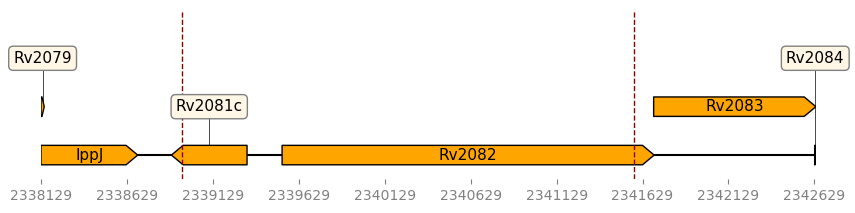

In [173]:
vertical_lines = [2338129, 2340759]  # absolute genome coordinates

region_start = h37Rv_regions.query("Name=='lppJ'").Start.values[0]
region_end   = h37Rv_regions.query("Name=='Rv2083'").Stop.values[0]

# --- Filter genes in region ---
df_region = h37Rv_regions.query("Stop >= @region_start & Start <= @region_end")

# --- Convert to GraphicFeatures ---
features = []
for _, row in df_region.iterrows():
    # Clip genes to the plotted region and make coordinates relative to region
    start = max(row["Start"], region_start) - region_start
    end   = min(row["Stop"], region_end) - region_start
    features.append(
        GraphicFeature(
            start=start,
            end=end,
            strand=1 if row["Strand"] == "+" else -1,
            color="orange",
            label=row["Name"]
        )
    )

# --- Create GraphicRecord ---
region_seq = h37Rv_seq.seq[region_start:region_end]
record = GraphicRecord(sequence=region_seq, features=features)

# --- Plot with scaled width ---
ax, _ = record.plot(figure_width=10)  # width in inches; scales automatically

# Add vertical lines relative to region
for x in vertical_lines:
    if region_start <= x <= region_end:
        ax.axvline(x=x - region_start, color="darkred", linestyle="--", linewidth=1, zorder=0)
        
ax.set_xticklabels([int(t + 2338129) for t in ax.get_xticks()])

plt.savefig("./duplicated_region.svg", bbox_inches='tight')


In [171]:
np.array(ax.get_xticklabels())

array([Text(0.0, 0, '0'), Text(500.0, 0, '500'), Text(1000.0, 0, '1,000'),
       Text(1500.0, 0, '1,500'), Text(2000.0, 0, '2,000'),
       Text(2500.0, 0, '2,500'), Text(3000.0, 0, '3,000'),
       Text(3500.0, 0, '3,500'), Text(4000.0, 0, '4,000'),
       Text(4500.0, 0, '4,500')], dtype=object)

# Delly on Illumina reads aligned to H37Rv

In [73]:
all_samples = os.listdir(H37Rv_ref_dir)
len(all_samples)

767

In [74]:
start = 2338129
end = 2340759

In [75]:
def read_in_delly_VCF(vcf_file):

    # Open the VCF
    vcf_reader = vcf.Reader(filename=vcf_file)

    # List to hold variant info
    records = []

    # Iterate over variants
    for record in vcf_reader:
        rec_dict = {
            "CHROM": record.CHROM,
            "POS": record.POS,
            "REF": record.REF,
            "ALT": ",".join([str(a) for a in record.ALT]),
            "QUAL": record.QUAL,
            "FILTER": ";".join(record.FILTER) if record.FILTER else "PASS",
            "IMPRECISE": record.INFO.get("IMPRECISE", False),
            "SVTYPE": record.INFO.get("SVTYPE", None),
            "SVEND": record.INFO.get("END", None),  # sometimes SVEND is END
            "MQ": record.INFO.get("MQ", None),
            "PE": record.INFO.get("PE", None),
            "CIPOS": record.INFO.get("CIPOS", None),
            "CIEND": record.INFO.get("CIEND", None),
            "RC": record.samples[0]['RC'],
            "RCL": record.samples[0]['RCL'],
            "RCR": record.samples[0]['RCR'],
            'RDCN': record.samples[0]['RDCN']
        }
        records.append(rec_dict)

    # Convert to DataFrame
    df = pd.DataFrame(records)
    
    return df

In [103]:
df_SV_SR_all = []

for sample in all_samples:
    
    # if os.path.isfile(f"{H37Rv_ref_dir}/{sample}/delly/{sample}.tsv"):
    #     df_SV = pd.read_csv(f"{H37Rv_ref_dir}/{sample}/delly/{sample}.tsv", sep='\t', header=None)
    #     df_SV.columns = ['CHROM', 'POS', 'REF', 'ALT', 'QUAL', 'FILTER', 'IMPRECISE', 'SVTYPE', 'SVEND', 'MQ', 'PE', 'CIPOS', 'CIEND', 'RC', 'RCL', 'RCR']
    #     df_SV['SampleID'] = sample
    #     df_SV_SR_all.append(df_SV)
    
    # Path to your VCF
    df_SV = read_in_delly_VCF(f"{H37Rv_ref_dir}/{sample}/delly/{sample}.vcf")
    df_SV['SampleID'] = sample
    df_SV_SR_all.append(df_SV)
    
df_SV_SR_all = pd.concat(df_SV_SR_all)
df_SV_SR_all['SVLEN'] = df_SV_SR_all['SVEND'] - df_SV_SR_all['POS']

df_SV_SR_all = df_SV_SR_all.merge(df_trust_patients.query("F2 <= @F2_max")[['SampleID', 'pid', 'Coll2014', 'Lineage', 'Sampling_Week']])
df_SV_SR_all = df_SV_SR_all.merge(tbtyper_culture)

print(df_SV_SR_all.SampleID.nunique())

738


In [77]:
L4_1_2_samples = df_trust_patients.query("Coll2014=='4.1.2'").SampleID.values
len(L4_1_2_samples)

8

In [506]:
df_SV_SR_all.query("POS >= @start & POS <= @end + 1000").query("SampleID in @L4_1_2_samples")



,CHROM,POS,REF,ALT,QUAL,FILTER,IMPRECISE,SVTYPE,SVEND,MQ,...,RDCN,SampleID,SVLEN,pid,Coll2014,Lineage,mix_phylotypes,mix_props,n_phy,defaultParams
10545,Chromosome,2338175,C,<DUP>,2043,PASS,True,DUP,2340761,None,...,4,MFS-308,2586,T0291,4.1.2,4,4.1.2,1.0,1,1
10604,Chromosome,2338214,G,<DUP>,2432,PASS,True,DUP,2340759,None,...,4,MFS-309,2545,T0291,4.1.2,4,4.1.2,1.0,1,1
30782,Chromosome,2338205,C,<DUP>,2010,PASS,True,DUP,2340759,None,...,3,MFS-559,2554,T0076,4.1.2,4,4.1.2,1.0,1,1
35801,Chromosome,2338213,G,<DUP>,1735,PASS,True,DUP,2340759,None,...,3,MFS-600,2546,T0137,4.1.2,4,4.1.2,1.0,1,1
45823,Chromosome,2338129,G,<DUP>,1643,PASS,True,DUP,2340761,None,...,3,MFS-701,2632,T0436,4.1.2,4,4.1.2,1.0,1,1
50208,Chromosome,2338214,G,<DUP>,1343,PASS,True,DUP,2340759,None,...,3,MFS-731,2545,T0076,4.1.2,4,4.1.2,1.0,1,1
52001,Chromosome,2338214,G,<DUP>,1928,PASS,True,DUP,2340759,None,...,3,MFS-746,2545,T0137,4.1.2,4,4.1.2,1.0,1,1
58147,Chromosome,2338208,C,<DUP>,1180,PASS,True,DUP,2340759,None,...,3,MFS-818,2551,T0436,4.1.2,4,4.1.2,1.0,1,1


In [104]:
df_candidate_SV = df_SV_SR_all.query("POS >= @start & POS <= @end & SVLEN >= 2500 & PE >= 10 & Sampling_Week <= 2")[['SampleID', 'pid', 'Sampling_Week', 'POS', 'REF', 'SVTYPE', 'RCL', 'RC', 'RCR', 'RDCN', 'SVLEN', 'Coll2014', 'mix_phylotypes', 'mix_props', 'Lineage']].reset_index(drop=True)

df_candidate_SV.SVLEN.min(), df_candidate_SV.SVLEN.max()

(2536, 2632)

In [105]:
df_candidate_SV.SampleID.nunique(), df_candidate_SV.pid.nunique()

(35, 34)

In [106]:
set(df_trust_patients.query("Sampling_Week <= 2 & Lineage in [3, '3']").SampleID).symmetric_difference(df_candidate_SV.query("Lineage=='3'").SampleID)

set()

In [108]:
df_candidate_SV.drop_duplicates(subset='pid').mix_phylotypes.value_counts()

mix_phylotypes
3.1.1.1             16
3.1.3.1              7
3.5.1                4
4.1.2                4
4.2.2.2              1
4.1                  1
2.2.M1.1,3.1.3.1     1
Name: count, dtype: int64

In [109]:
df_candidate_SV.drop_duplicates(subset='pid').Coll2014.value_counts()

Coll2014
3.1.1    16
3        12
4.1.2     4
4.2.2     1
4.1       1
Name: count, dtype: int64

In [92]:
df_SV_SR_all.query("POS >= @start & POS <= @end & SVLEN >= 2500 & PE >= 10").drop_duplicates(subset='pid').Coll2014.value_counts()

Coll2014
3.1.1      18
3          14
4.1.2       4
4.1.1.2     2
4.2.2       1
4.1         1
Name: count, dtype: int64

In [ ]:
4 L4.1.2, 2 L4.1.1.2, 1 L4.2.2, and 1 L4.1

In [410]:
df_SV_SR_all.query("POS >= @start & POS <= @end & SVLEN >= 2500 & PE >= 10").Coll2014.unique()

array(['3.1.1', '3', '4.1.1.2', '4.1.2', '4.2.2', '4.1'], dtype=object)

In [414]:
samples_lineage_annot = pd.read_csv("~/MtbLongitudinalDiversity/lowAF_variant_calling/data/trees/samples_lineage_annot.tsv", sep='\t')

In [416]:
samples_with_dup = df_SV_SR_all.query("POS >= @start & POS <= @end & SVLEN >= 2500 & PE >= 10").SampleID.unique()

In [436]:
df_SV_SR_all.query("POS >= @start & POS <= @end & SVLEN >= 2400 & PE >= 10 & Lineage=='4'").sort_values('SampleID')

,CHROM,POS,REF,ALT,QUAL,FILTER,IMPRECISE,SVTYPE,SVEND,MQ,PE,CIPOS,CIEND,SampleID,SVLEN,pid,Coll2014,Lineage
8280,Chromosome,2338129,G,<DUP>,5899,PASS,1,DUP,2340759,60,131,"-82,82","-82,82",MFS-273,2630,T0273,4.1.1.2,4
10545,Chromosome,2338175,C,<DUP>,2043,PASS,1,DUP,2340761,60,35,"-250,250","-250,250",MFS-308,2586,T0291,4.1.2,4
10604,Chromosome,2338214,G,<DUP>,2432,PASS,1,DUP,2340759,60,45,"-50,50","-50,50",MFS-309,2545,T0291,4.1.2,4
13442,Chromosome,2338129,G,<DUP>,3639,PASS,1,DUP,2340761,60,80,"-161,161","-161,161",MFS-35,2632,T0056,4.2.2,4
13969,Chromosome,2338129,G,<DUP>,4014,PASS,1,DUP,2340761,60,88,"-71,71","-71,71",MFS-36,2632,T0056,4.2.2,4
30782,Chromosome,2338205,C,<DUP>,2010,PASS,1,DUP,2340759,60,35,"-230,230","-230,230",MFS-559,2554,T0076,4.1.2,4
34052,Chromosome,2338129,G,<DUP>,6112,PASS,1,DUP,2340761,60,127,"-59,59","-59,59",MFS-588,2632,T0125,4.1,4
34188,Chromosome,2338129,G,<DUP>,3767,PASS,1,DUP,2340761,60,76,"-50,50","-50,50",MFS-589,2632,T0125,4.1,4
35801,Chromosome,2338213,G,<DUP>,1735,PASS,1,DUP,2340759,60,32,"-237,237","-237,237",MFS-600,2546,T0137,4.1.2,4
45823,Chromosome,2338129,G,<DUP>,1643,PASS,1,DUP,2340761,60,30,"-70,70","-70,70",MFS-701,2632,T0436,4.1.2,4


In [435]:
df_trust_patients.query("SampleID in ['MFS-395']")

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov Any Mean,Cov Unam Perc,Perc. Reads Mapped,...,duration_of_use_meth,duration_of_use_mandrax,lca,fib4,prevtb_outcome,F2,Coll2014,Freschi2020,Lineage,Sampling_Week
424,T0330,S0330-01,MFS-395,MFS-395_lib59210,NaN,NaN,1.0,213.37,0.99,0.986,...,NaN,NaN,1.0,0.259194,1.0,0.006105,4.1.1.1,4.1.i1.2.1,4,1


In [431]:
df_trust_patients.query("SampleID in ['MFS-588', 'MFS-716', 'MFS-334']").drop_duplicates(subset='SampleID')

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov Any Mean,Cov Unam Perc,Perc. Reads Mapped,...,duration_of_use_meth,duration_of_use_mandrax,lca,fib4,prevtb_outcome,F2,Coll2014,Freschi2020,Lineage,Sampling_Week
249,T0455,S0455-01,MFS-716,MFS-716_lib66589,NaN,NaN,1.0,395.47,1.0,0.9844,...,15.0,23.0,2.0,0.326161,NaN,0.019856,4.1.1.2,4.1.i1.2.1,4,1
351,T0125,S0125-01,MFS-588,MFS-588_lib65694,NaN,NaN,1.0,388.97,1.0,0.9794,...,NaN,NaN,1.0,0.412089,NaN,0.023414,4.1,4.1.i1.2.2,4,1
453,T0009,S0009-01,MFS-334,MFS-334_lib58946,NaN,NaN,1.0,394.04,1.0,0.9896,...,NaN,NaN,3.0,0.381709,NaN,0.021540,4.1.2.1,4.1.i1.1.1.1,4,1


In [419]:
samples_lineage_annot.loc[(samples_lineage_annot['SampleID'].isin(samples_with_dup)) & (samples_lineage_annot['Lineage']=='4'), 'Lineage'] = '4 DUP'

In [420]:
samples_lineage_annot.Lineage.unique()

array(['4', '2', '3', '1', '4 DUP'], dtype=object)

In [421]:
samples_lineage_annot.to_csv("~/MtbLongitudinalDiversity/lowAF_variant_calling/data/trees/samples_lineage_annot.tsv", sep='\t', index=False)

In [ ]:
The other 6 L4.1.2 samples do not have PacBio sequencing, 

In [110]:
def read_in_sniffles_SVs(fName, START, END):
    
    df_SV = []

    vcf_reader = vcf.Reader(filename=fName)

    for record in vcf_reader:
        
        pos = record.POS
        
        if pos >= START and pos <= END:
            
            ref = record.REF
            alt = ''.join([str(a) for a in record.ALT]).strip('<').strip('>')      # ALT is a list of objects
            qual = record.QUAL
            flt = record.FILTER if record.FILTER else "PASS"
            
            info = {k: record.INFO[k] for k in record.INFO}
            
            if 'PRECISE' in info.keys():
                imprecise_bool = not(info['PRECISE'])
            else:
                imprecise_bool = False
        
            df_SV.append(pd.DataFrame({'POS': pos, 'REF': ref, 'ALT': alt, 'QUAL': qual, 'FILTER': flt, 'IMPRECISE': imprecise_bool, 
                                       'SVTYPE': info['SVTYPE'], 'END': info['END'], 'VAF': info['VAF'],
                                      }, index=[0])
                        )
    
    if len(df_SV) > 0:
        df_SV = pd.concat(df_SV)
        df_SV['ROLLINGDB_ID'] = os.path.basename(fName).split('.vcf')[0]
        df_SV['SVLEN'] = df_SV['END'] - df_SV['POS']

        return df_SV.set_index('ROLLINGDB_ID').reset_index()
    else:
        return pd.DataFrame()
    

# Delly on Illumina reads aligned to H37Rv in rollingDB

In [28]:
# delly_fNames = glob.glob(f"{genomic_data_dir}/*/delly/*.vcf")
# len(delly_fNames)

47942

In [143]:
delly_fNames = pd.read_csv("delly_fNames.txt", sep='\t', header=None)[0].values
len(delly_fNames)


47942

In [144]:
samples_with_delly = [os.path.basename(fName).split('.vcf')[0] for fName in delly_fNames]
len(samples_with_delly)


47942

In [145]:
df_rollingDB_lineages = pd.read_csv("rollingDB_lineages.csv")



In [146]:
df_SV_SR_rollingDB = pd.read_csv("rollingDB_Rv2082_SV.csv")
len(df_SV_SR_rollingDB)



54076

In [147]:
df_rollingDB_lineages.query("ROLLINGDB_ID in @samples_with_delly").Lineage.value_counts().sort_index()



Lineage
1            3294
2           14211
3            5133
4           24927
5              60
6               1
7              34
BOV             1
BOV_AFRI      227
canettii       11
Name: count, dtype: int64

In [150]:
start, end

(2338129, 2340759)

In [164]:
df_SV_SR_rollingDB.query("POS >= @start & POS <= @end & PE >= 10 & SVLEN > 2000 & SVLEN < 100000 & SVTYPE in ['DUP', 'INS']").merge(df_rollingDB_lineages[['ROLLINGDB_ID', 'Coll2014', 'F2', 'Lineage']]).sort_values('SVLEN').Lineage.value_counts()

Lineage
3           1059
4            766
5             12
BOV_AFRI      10
7              3
2              2
Name: count, dtype: int64

In [167]:
df_SV_SR_rollingDB.query("POS >= @start & POS <= @end & PE >= 10 & SVTYPE in ['DUP', 'INS']").merge(df_rollingDB_lineages[['ROLLINGDB_ID', 'Coll2014', 'F2', 'Lineage']]).query("Lineage not in ['3', '4']")

,ROLLINGDB_ID,POS,REF,ALT,QUAL,FILTER,IMPRECISE,SVTYPE,END,MQ,PE,DV,CIPOS_LB,CIPOS_UB,CIEND_LB,CIEND_UB,SVLEN,Coll2014,F2,Lineage
32,SAMEA104061141,2338129,G,DUP,4683,PASS,True,DUP,2340759,60,80,80,-83,83,-83,83,2630,7,0.017436,7
33,SAMEA104061144,2338129,G,DUP,1980,PASS,True,DUP,2340759,60,33,34,-98,98,-98,98,2630,7,0.012972,7
34,SAMEA104061155,2338129,G,DUP,3885,PASS,True,DUP,2340759,60,65,66,-50,50,-50,50,2630,7,0.011615,7
149,SAMEA1117570,2338129,G,DUP,2193,PASS,True,DUP,2340760,60,38,39,-183,183,-183,183,2631,BOV_AFRI,0.023702,BOV_AFRI
153,SAMEA1117714,2338129,G,DUP,890,PASS,True,DUP,2340759,60,16,16,-50,50,-50,50,2630,BOV_AFRI,0.015919,BOV_AFRI
159,SAMEA1118040,2338129,G,DUP,1098,PASS,True,DUP,2340761,60,19,19,-261,261,-261,261,2632,BOV_AFRI,0.020649,BOV_AFRI
184,SAMEA1119386,2338129,G,DUP,600,PASS,True,DUP,2340759,60,10,10,-208,208,-208,208,2630,5,0.024808,5
233,SAMEA1397442,2338129,G,DUP,2658,PASS,True,DUP,2340759,60,47,48,-128,128,-128,128,2630,BOV_AFRI,0.023823,BOV_AFRI
315,SAMEA1569365,2338129,G,DUP,2216,PASS,True,DUP,2340759,60,39,39,-50,50,-50,50,2630,BOV_AFRI,0.014393,BOV_AFRI
370,SAMEA2534584,2338129,G,DUP,953,PASS,True,DUP,2340759,60,17,17,-56,56,-56,56,2630,5,0.012340,5


In [44]:
def get_num_BAMs_merged(sample):
    
    pass_BAMs = pd.read_csv(f"{genomic_data_dir}/{sample}/bam/pass_BAMs.txt", sep='\t', header=None)[0].values
    
    return len(pass_BAMs)

In [45]:
# require that the start and end positions are not too uncertain (so confidence interval is within 20 base pairs long)
df_SV_SR_rollingDB_high_quality = df_SV_SR_rollingDB.query("FILTER=='PASS' & IMPRECISE==False & SVLEN >= 2500 & SVLEN <= 2700 & CIPOS_LB >= -10 & CIPOS_UB <= 10 & CIEND_LB >= -10 & CIEND_UB <= 10")

df_SV_SR_rollingDB_high_quality = df_SV_SR_rollingDB_high_quality.merge(df_rollingDB_lineages[['ROLLINGDB_ID', 'Coll2014', 'F2', 'Lineage']], how='left')

df_SV_SR_rollingDB_high_quality = df_SV_SR_rollingDB_high_quality.query("F2 <= @F2_max")

df_SV_SR_rollingDB_high_quality['Num_BAMs'] = df_SV_SR_rollingDB_high_quality['ROLLINGDB_ID'].apply(get_num_BAMs_merged)
df_SV_SR_rollingDB_high_quality = df_SV_SR_rollingDB_high_quality.query("Num_BAMs == 1")

df_SV_SR_rollingDB_high_quality.SVTYPE.value_counts()

SVTYPE
DUP    539
INV     17
DEL     11
Name: count, dtype: int64

In [173]:
df_SV_SR_rollingDB.query("FILTER=='PASS' & IMPRECISE==False & SVLEN >= 5000 & SVLEN <= 5400 & CIPOS_LB >= -10 & CIPOS_UB <= 10 & CIEND_LB >= -10 & CIEND_UB <= 10").merge(df_rollingDB_lineages[['ROLLINGDB_ID', 'Coll2014']])


,ROLLINGDB_ID,POS,REF,ALT,QUAL,FILTER,IMPRECISE,SVTYPE,END,MQ,PE,DV,CIPOS_LB,CIPOS_UB,CIEND_LB,CIEND_UB,SVLEN,Coll2014
0,SAMN30953404,2338305,G,DUP,5040,PASS,False,DUP,2343326,60,64,64,-5,5,-5,5,5021,2.2.1
1,SAMN31023090,2338305,G,DUP,2160,PASS,False,DUP,2343326,60,16,16,-5,5,-5,5,5021,2.2.1


In [176]:
df_SV_SR_rollingDB_high_quality.query("Coll2014=='4.1.2'")

,ROLLINGDB_ID,POS,REF,ALT,QUAL,FILTER,IMPRECISE,SVTYPE,END,MQ,...,DV,CIPOS_LB,CIPOS_UB,CIEND_LB,CIEND_UB,SVLEN,Coll2014,F2,Lineage,Num_BAMs
24,SAMEA104153448,2338099,C,DUP,1194,PASS,False,DUP,2340754,0,...,0,-6,6,-6,6,2655,4.1.2,0.025741,4,1
78,SAMEA104394538,2338099,C,DUP,420,PASS,False,DUP,2340754,0,...,0,-6,6,-6,6,2655,4.1.2,0.022066,4,1
80,SAMEA104394589,2338099,C,DUP,360,PASS,False,DUP,2340754,0,...,0,-6,6,-6,6,2655,4.1.2,0.022147,4,1
81,SAMEA104394592,2338099,C,DUP,480,PASS,False,DUP,2340754,0,...,0,-6,6,-6,6,2655,4.1.2,0.021675,4,1
174,SAMEA2709689,2338099,C,DUP,300,PASS,False,DUP,2340754,0,...,0,-6,6,-6,6,2655,4.1.2,0.028079,4,1
175,SAMEA2709724,2338099,C,DUP,420,PASS,False,DUP,2340754,0,...,0,-6,6,-6,6,2655,4.1.2,0.029498,4,1
181,SAMEA3178851,2338099,C,DUP,300,PASS,False,DUP,2340754,0,...,0,-6,6,-6,6,2655,4.1.2,0.026910,4,1
182,SAMEA3178929,2338099,C,DUP,360,PASS,False,DUP,2340754,0,...,0,-6,6,-6,6,2655,4.1.2,0.026953,4,1
186,SAMEA3230404,2338099,C,DUP,1020,PASS,False,DUP,2340754,0,...,0,-6,6,-6,6,2655,4.1.2,0.018282,4,1
187,SAMEA3230405,2338099,C,DUP,540,PASS,False,DUP,2340754,0,...,0,-6,6,-6,6,2655,4.1.2,0.026546,4,1


In [46]:
df_SV_SR_rollingDB_high_quality.query("SVTYPE=='DUP'").SVLEN.value_counts()

SVLEN
2655    533
2590      2
2653      1
2654      1
2660      1
2607      1
Name: count, dtype: int64

In [48]:
df_SV_SR_rollingDB_high_quality.query("SVTYPE=='DUP'").Coll2014.value_counts().sort_index()

Coll2014
2.2.1         1
3            96
3.1.1        35
3.1.2         8
3.1.2.1       3
4.1          22
4.1.1        67
4.1.1.2      19
4.1.2        34
4.2.1        74
4.2.2       108
4.2.2.1      34
5            13
7            20
BOV_AFRI      5
Name: count, dtype: int64

In [53]:
df_SV_SR_rollingDB_high_quality.query("SVTYPE=='DUP'").query("Lineage in ['5', '7']")

,ROLLINGDB_ID,POS,REF,ALT,QUAL,FILTER,IMPRECISE,SVTYPE,END,MQ,...,DV,CIPOS_LB,CIPOS_UB,CIEND_LB,CIEND_UB,SVLEN,Coll2014,F2,Lineage,Num_BAMs
4,SAMEA104061138,2338099,C,DUP,6552,PASS,False,DUP,2340754,60,...,94,-6,6,-6,6,2655,7,0.022914,7,1
5,SAMEA104061139,2338099,C,DUP,5667,PASS,False,DUP,2340754,60,...,75,-6,6,-6,6,2655,7,0.009850,7,1
6,SAMEA104061143,2338099,C,DUP,6984,PASS,False,DUP,2340754,60,...,99,-6,6,-6,6,2655,7,0.019545,7,1
7,SAMEA104061145,2338099,C,DUP,3372,PASS,False,DUP,2340754,60,...,37,-6,6,-6,6,2655,7,0.011775,7,1
8,SAMEA104061146,2338099,C,DUP,3918,PASS,False,DUP,2340754,60,...,47,-6,6,-6,6,2655,7,0.012160,7,1
9,SAMEA104061147,2338099,C,DUP,4848,PASS,False,DUP,2340754,60,...,64,-6,6,-6,6,2655,7,0.019636,7,1
10,SAMEA104061148,2338099,C,DUP,4525,PASS,False,DUP,2340754,60,...,56,-6,6,-6,6,2655,7,0.011276,7,1
11,SAMEA104061149,2338099,C,DUP,3120,PASS,False,DUP,2340754,60,...,33,-6,6,-6,6,2655,7,0.011101,7,1
12,SAMEA104061150,2338099,C,DUP,3660,PASS,False,DUP,2340754,60,...,41,-6,6,-6,6,2655,7,0.011920,7,1
13,SAMEA104061152,2338099,C,DUP,6881,PASS,False,DUP,2340754,60,...,96,-6,6,-6,6,2655,7,0.019222,7,1


In [47]:
df_SV_SR_rollingDB_high_quality.query("SVTYPE=='DUP'").Lineage.value_counts().sort_index()

Lineage
2             1
3           142
4           358
5            13
7            20
BOV_AFRI      5
Name: count, dtype: int64